In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/images.zip' # আপনার জিপ ফাইলের পাথ
extract_path = '/content/dataset' # যেখানে ফাইলগুলো আনজিপ হবে

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzip সম্পন্ন হয়েছে।")

Unzip সম্পন্ন হয়েছে।


In [3]:
import glob
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# আপনার ডাটাসেট পাথ
root_dir = '/content/dataset/Images'
all_image_paths = glob.glob(root_dir + '/**/train_val_photos/**/*.png', recursive=True) + \
                  glob.glob(root_dir + '/**/train_val_photos/**/*.jpg', recursive=True)

class_to_idx = {'Double': 0, 'Empty': 1, 'Single': 2}
images_with_labels = []

for path in all_image_paths:
    label_name = path.split('/')[-2]
    if label_name in class_to_idx:
        images_with_labels.append((path, class_to_idx[label_name]))

print(f"Total images: {len(images_with_labels)}")
# ক্লাস ডিস্ট্রিবিউশন চেক
counts = {k: 0 for k in class_to_idx}
for _, label in images_with_labels:
    for name, idx in class_to_idx.items():
        if label == idx: counts[name] += 1
print(f"Class Distribution: {counts}")

Total images: 26474
Class Distribution: {'Double': 7616, 'Empty': 7826, 'Single': 11032}


In [6]:
import numpy as np

# ১. র‍্যান্ডমলি শাফলিং এবং স্প্লিট করা
np.random.seed(42)
np.random.shuffle(images_with_labels)

# ২০% ছবি টেস্টের জন্য আলাদা রাখা
split = int(0.2 * len(images_with_labels))
test_list = images_with_labels[:split]
train_list = images_with_labels[split:]

# ট্রেনিং লিস্টের ভেতর থেকে ১০% লেবেলড ডাটা নেওয়া
n_labeled = int(0.1 * len(train_list))
labeled_list = train_list[:n_labeled]
unlabeled_list = train_list[n_labeled:]

print(f"Labeled: {len(labeled_list)}")
print(f"Unlabeled: {len(unlabeled_list)}")
print(f"Test: {len(test_list)}")

Labeled: 2118
Unlabeled: 19062
Test: 5294


In [7]:
# ৩. লোডার তৈরি করা
labeled_loader = DataLoader(AAVDataset(labeled_list, basic_transform), batch_size=16, shuffle=True, drop_last=True)
unlabeled_loader = DataLoader(AAVDataset(unlabeled_list, FixMatchTransform()), batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(AAVDataset(test_list, basic_transform), batch_size=16, shuffle=False)

print("DataLoader তৈরি হয়েছে সফলভাবে!")

DataLoader তৈরি হয়েছে সফলভাবে!


In [8]:
# ১. অগমেন্টেশন এবং ট্রান্সফর্ম ডিফাইন করা
class FixMatchTransform(object):
    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.weak = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
        ])
        self.strong = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET)
        ])
        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    def __call__(self, x):
        return self.normalize(self.weak(x)), self.normalize(self.strong(x))

# Labeled এবং Test ডাটার জন্য বেসিক ট্রান্সফর্ম
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# ২. ডাটাসেট ক্লাস (যদি আগে রান না করে থাকেন)
class AAVDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self): return len(self.data_list)
    def __getitem__(self, idx):
        path, label = self.data_list[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

# ৩. লোডার তৈরি করা (এখন basic_transform ডিফাইন করা আছে)
labeled_loader = DataLoader(AAVDataset(labeled_list, basic_transform), batch_size=16, shuffle=True, drop_last=True)
unlabeled_loader = DataLoader(AAVDataset(unlabeled_list, FixMatchTransform()), batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(AAVDataset(test_list, basic_transform), batch_size=16, shuffle=False)

print("DataLoader তৈরি হয়েছে সফলভাবে!")

DataLoader তৈরি হয়েছে সফলভাবে!


In [10]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

# মডেল সেটআপ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3) # ৩টি ক্লাসের জন্য
model = model.to(device)

# অপ্টিমাইজার
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, nesterov=True)

def train_epoch(epoch):
    model.train()
    for (inputs_x, labels_x), ((inputs_u_w, inputs_u_s), _) in zip(labeled_loader, unlabeled_loader):
        inputs_x, labels_x = inputs_x.to(device), labels_x.to(device)
        inputs_u_w, inputs_u_s = inputs_u_w.to(device), inputs_u_s.to(device)

        # ১. Supervised Loss
        logits_x = model(inputs_x)
        lx = F.cross_entropy(logits_x, labels_x)

        # ২. FixMatch Unsupervised Loss
        if epoch >= 2: # Warm-up এর পর শুরু হবে
            with torch.no_grad():
                logits_u_w = model(inputs_u_w)
                probs = torch.softmax(logits_u_w, dim=-1)
                max_probs, targets_u = torch.max(probs, dim=-1)
                mask = max_probs.ge(0.95).float()

            logits_u_s = model(inputs_u_s)
            lu = (F.cross_entropy(logits_u_s, targets_u, reduction='none') * mask).mean()
        else:
            lu = 0

        loss = lx + lu
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# ১৫ এপোক পর্যন্ত ট্রেনিং শুরু করুন
for epoch in range(15):
    train_epoch(epoch)
    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.
Epoch 11 completed.
Epoch 12 completed.
Epoch 13 completed.
Epoch 14 completed.
Epoch 15 completed.


              precision    recall  f1-score   support

      Double       0.94      0.86      0.90      1528
       Empty       0.86      0.82      0.84      1522
      Single       0.84      0.92      0.88      2244

    accuracy                           0.87      5294
   macro avg       0.88      0.87      0.87      5294
weighted avg       0.88      0.87      0.87      5294



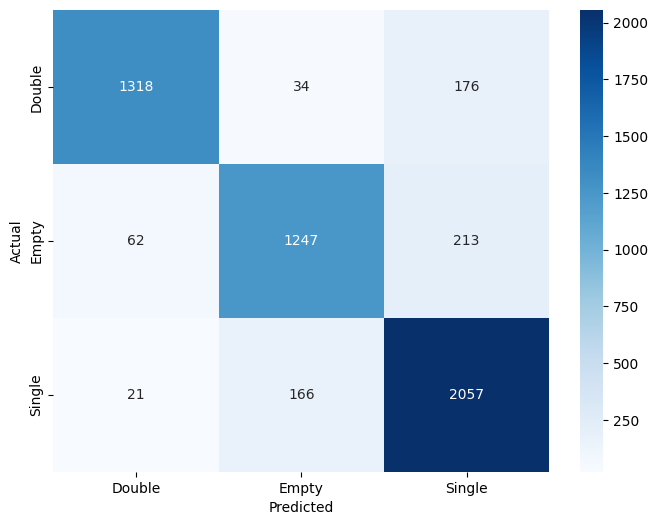

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def final_report(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    class_names = ['Double', 'Empty', 'Single']
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

final_report(model, test_loader)